# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


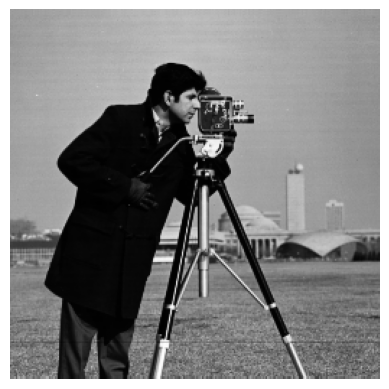

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.png")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image

# scaling factors
width, height = img.size

cx = 2
cy = 2

new_width = int(width * cx)
new_height = int(height * cy)

print("Original size:", img.size)
print("New size:", (new_width, new_height))

Original size: (256, 256)
New size: (512, 512)


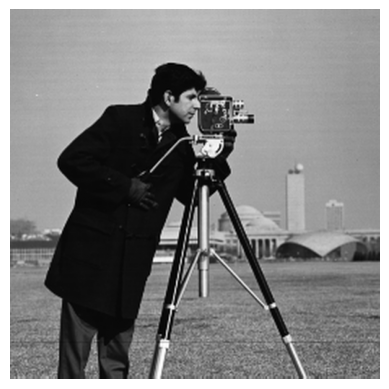

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

scaled_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

plt.imshow(scaled_img, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (256, 256)
Scaled size: (512, 512)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

print("Original size:", img.size)
print("New size:", (new_width, new_height))

Original size: (256, 256)
New size: (512, 256)


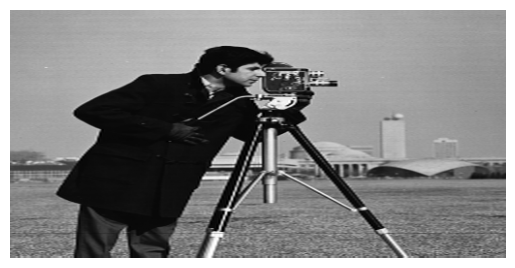

In [7]:
non_uniform_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

plt.imshow(non_uniform_img, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
non_uniform_img.save("task1_1_non_uniform.jpg")

print("Original size:", img.size)
print("Non-uniform size:", non_uniform_img.size)

Original size: (256, 256)
Non-uniform size: (512, 256)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

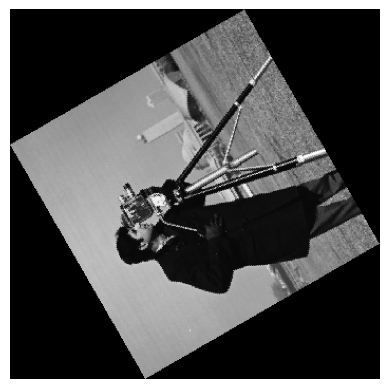

Original size: (256, 256)
Rotated size: (350, 350)


In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)

plt.imshow(rotated_img, cmap="gray")
plt.axis("off")
plt.show()

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Width:", width)
print("Height:", height)

Width: 256
Height: 256


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shx = shear_factor
shy = 0

shear_matrix = (1, -shx, 0,
                0, 1, 0)

print("Shear matrix:", shear_matrix)

Shear matrix: (1, -0.5, 0, 0, 1, 0)


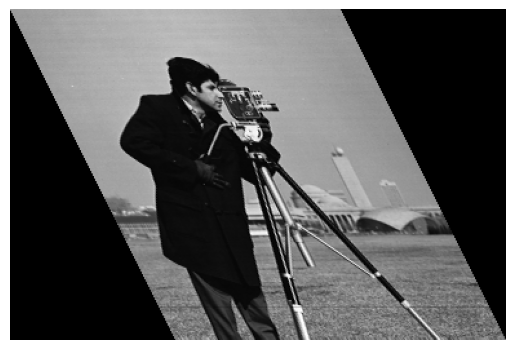

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + abs(shear_factor * height))

sheared_img = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.imshow(sheared_img, cmap="gray")
plt.axis("off")
plt.show()

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (256, 256)
Sheared size: (384, 256)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

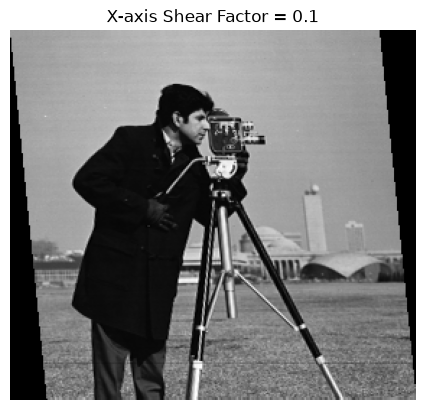

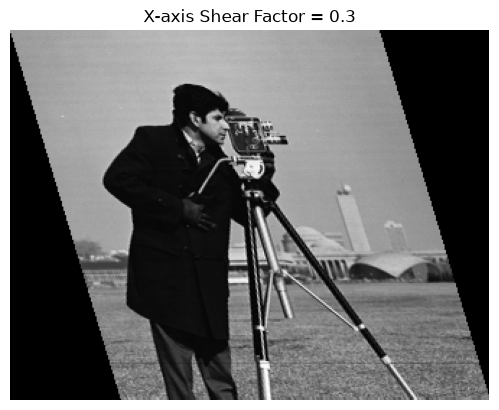

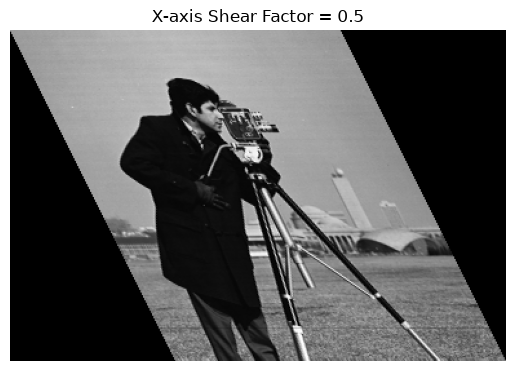

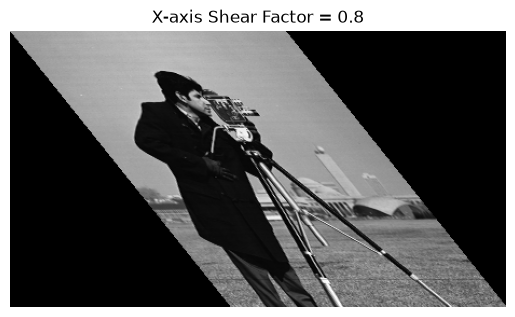

In [14]:
# Experiment and compare

# 1. Change shear factor
for shear_factor in [0.1, 0.3, 0.5, 0.8]:
    shx = shear_factor
    shy = 0

    shear_matrix = (1, -shx, 0,
                    0, 1, 0)

    new_width = int(width + abs(shear_factor * height))

    sheared = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        shear_matrix,
        resample=Image.Resampling.BICUBIC
    )

    plt.figure()
    plt.imshow(sheared, cmap="gray")
    plt.title(f"X-axis Shear Factor = {shear_factor}")
    plt.axis("off")
    plt.show()

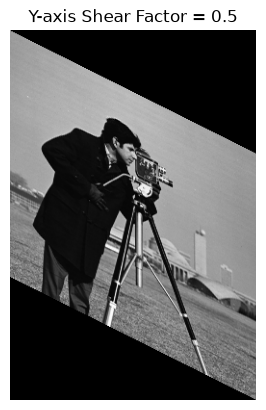

In [15]:
# 2. Y-axis shear

shear_factor = 0.5

shy = shear_factor
shx = 0

shear_matrix_y = (
    1, 0, 0,
    -shy, 1, 0
)

new_height = int(height + abs(shear_factor * width))

sheared_y = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    shear_matrix_y,
    resample=Image.Resampling.BICUBIC
)

plt.figure()
plt.imshow(sheared_y, cmap="gray")
plt.title("Y-axis Shear Factor = 0.5")
plt.axis("off")
plt.show()

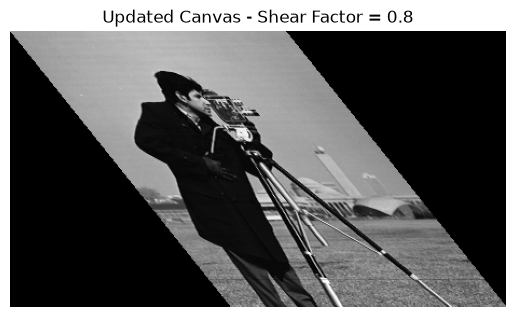

Original size: (256, 256)
New canvas size: (460, 256)


In [22]:
# 3. Update the canvas size for a new shear factor

shear_factor = 0.8

shx = shear_factor

shear_matrix = (
    1, -shx, 0,
    0, 1, 0
)

new_width = int(width + abs(shear_factor * height))

sheared_new = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.imshow(sheared_new, cmap="gray")
plt.title(f"Updated Canvas - Shear Factor = {shear_factor}")
plt.axis("off")
plt.show()

print("Original size:", img.size)
print("New canvas size:", sheared_new.size)

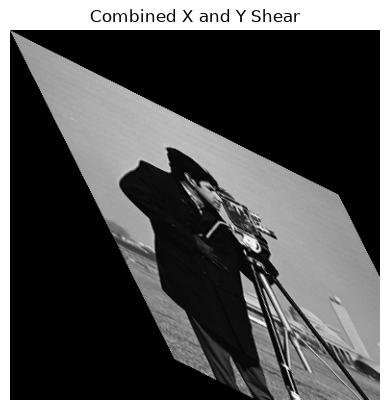

In [17]:
# 4. Combine X and Y shear

shx = 0.5
shy = 0.5

combined_matrix = (
    1, -shx, 0,
    -shy, 1, 0
)

new_width = int(width + abs(shx * height))
new_height = int(height + abs(shy * width))

combined_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.figure()
plt.imshow(combined_shear, cmap="gray")
plt.title("Combined X and Y Shear")
plt.axis("off")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

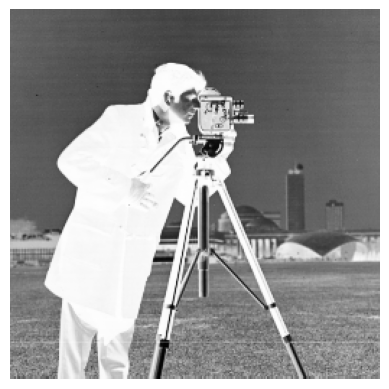

In [18]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array.astype(np.uint8))

plt.imshow(negative_img, cmap="gray")
plt.axis("off")
plt.show()

negative_img.save("negative_numpy.jpg")

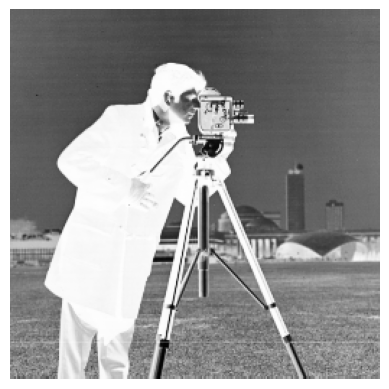

In [19]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)

plt.imshow(negative_img_pil, cmap="gray")
plt.axis("off")
plt.show()

negative_img_pil.save("negative_pil.jpg")

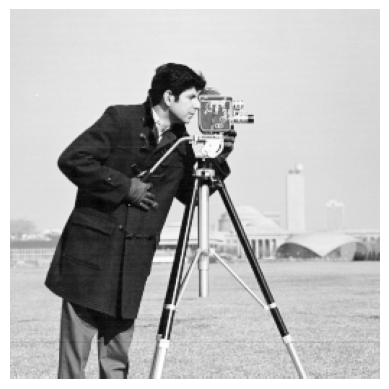

In [20]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
img_array = np.array(img).astype(float)

c = 255 / np.log(1 + 255)

log_array = c * np.log(1 + img_array)

log_array = np.clip(log_array, 0, 255)

log_array = log_array.astype(np.uint8)

log_img = Image.fromarray(log_array)

plt.imshow(log_img, cmap="gray")
plt.axis("off")
plt.show()

log_img.save("log_transformation.jpg")

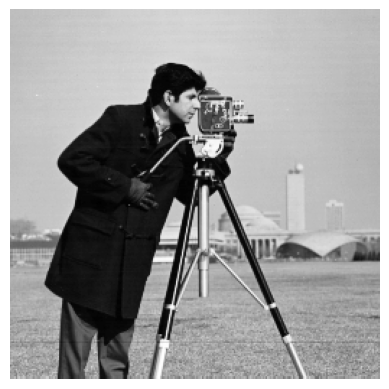

In [21]:

# ── 3. Power-law / Gamma correction ───────────────
img_array = np.array(img).astype(float) / 255.0

gamma = 0.5

gamma_array = 255 * (img_array ** gamma)

gamma_array = np.clip(gamma_array, 0, 255)

gamma_array = gamma_array.astype(np.uint8)

gamma_img = Image.fromarray(gamma_array)

plt.imshow(gamma_img, cmap="gray")
plt.axis("off")
plt.show()

gamma_img.save("gamma_transformation.jpg")